In [1]:
import pandas as pd
import matplotlib as mpl
mpl.use('svg')
mpl.rcParams.update({'svg.fonttype': 'none'})

In [2]:
df = pd.read_excel('../../data/20250924_BUSCO_Au3_Pgt.xlsx', header=0)

In [3]:
df_Au3_hapA = df[df['Genome'].str.contains('AuhapA' )]
df_Au3_hapB = df[df['Genome'].str.contains('AuhapB' )]
df_Pgt_hapA = df[df['Genome'].str.contains('PgthapA' )]
df_Pgt_hapB = df[df['Genome'].str.contains('PgthapB' )]

In [4]:
df_Au3 = df[df['Genome'].str.contains('Au' )]
df_Pgt = df[df['Genome'].str.contains('Pgt' )]

In [5]:
df_Au3_hapA

,Genome,SeqName,Start,End,Strand,BuscoID
0,AuhapA,APSI_AU3_HapA_CHR01,648035,649003,+,64982at5204
1,AuhapA,APSI_AU3_HapA_CHR01,1586229,1587021,+,70561at5204
2,AuhapA,APSI_AU3_HapA_CHR01,2320950,2322828,+,53888at5204
3,AuhapA,APSI_AU3_HapA_CHR01,3267396,3263203,-,4662at5204
4,AuhapA,APSI_AU3_HapA_CHR01,4031267,4032278,+,74336at5204
...,...,...,...,...,...,...
1588,AuhapA,APSI_AU3_HapA_CHR18,24942053,24940941,-,61882at5204
1589,AuhapA,APSI_AU3_HapA_CHR18,25896574,25898363,+,54194at5204
1590,AuhapA,APSI_AU3_HapA_CHR18,26040577,26041986,+,32623at5204
1591,AuhapA,APSI_AU3_HapA_CHR18,26419649,26417892,-,38878at5204


In [5]:
busco_id_Au3_hapA = set(df_Au3_hapA['BuscoID'])
busco_id_Au3_hapB = set(df_Au3_hapB['BuscoID'])
busco_id_Pgt_hapA = set(df_Pgt_hapA['BuscoID'])
busco_id_Pgt_hapB = set(df_Pgt_hapB['BuscoID'])
#Find common BuscoIDs
common_Au3_hapA_hapB = busco_id_Au3_hapA.intersection(busco_id_Au3_hapB)
common_Pgt_hapA_hapB = busco_id_Pgt_hapA.intersection(busco_id_Pgt_hapB)
common_Au3_Pgt = common_Au3_hapA_hapB.intersection(common_Pgt_hapA_hapB)

In [6]:
df_Au3_Pgt_common = df[df['BuscoID'].isin(common_Au3_Pgt)]
df_Au3 = df_Au3_Pgt_common[df_Au3_Pgt_common['Genome'].str.contains('Au' )]
df_Pgt = df_Au3_Pgt_common[df_Au3_Pgt_common['Genome'].str.contains('Pgt' )]
#If genome contains' hapA', add A for Pgt, B for hapB
df_Pgt = df_Pgt.copy()
df_Pgt['SeqName'] = df_Pgt.apply(lambda row: row['SeqName'] + 'A' if 'hapA' in row['Genome'] else row['SeqName'] + 'B', axis=1)

In [8]:
#Merge the two dataframes on BuscoID
df_Au3_Pgt_merged = pd.merge(df_Au3, df_Pgt, on='BuscoID', suffixes=('_Au3', '_Pgt')).groupby(['SeqName_Au3', 'SeqName_Pgt']).size().reset_index(name='Count')
df_Au3_Pgt_merged_count = df_Au3_Pgt_merged.copy()
df_Au3_Pgt_merged_count['SeqName_Au3'] = df_Au3_Pgt_merged_count['SeqName_Au3'].apply(lambda row: row + 'A' if 'HapA' in row else row + 'B')
df_Au3_Pgt_merged_count['SeqName_Au3'] = df_Au3_Pgt_merged_count['SeqName_Au3'].str.split('_').str[-1].str.replace('CHR', 'Chr')
df_Au3_Pgt_merged_count['SeqName_Pgt'] = df_Au3_Pgt_merged_count['SeqName_Pgt'].str.replace('_', '').str.replace('chr', 'Chr')
df_Au3_Pgt_merged_count['SeqName_Au3_no'] = df_Au3_Pgt_merged_count['SeqName_Au3'].str.replace('Chr', '').str.replace('A', '').str.replace('B', '')
df_Au3_Pgt_merged_count['SeqName_Pgt_no'] = df_Au3_Pgt_merged_count['SeqName_Pgt'].str.replace('Chr', '').str.replace('A', '').str.replace('B', '')
df_Au3_Pgt_pivot = df_Au3_Pgt_merged_count.pivot(index='SeqName_Au3', columns='SeqName_Pgt', values='Count').fillna(0)
#tmp_orderau3 = df_Au3_Pgt_merged_count.sort_values(by=['Count', 'SeqName_Au3_no', 'SeqName_Pgt_no'], ascending=False)['SeqName_Au3_no'].unique()
#Repeat number for tmp_orderau3, add And B, sort by number
tmp_orderau3 = [f"{i:02d}" for i in range(1, 19)]
tmp_orderpgt = [f"{i:02d}" for i in range(1, 19)]
tmp_orderau3_list = []
for i in tmp_orderau3:
    tmp_orderau3_list.append(f'Chr{i}A')
    tmp_orderau3_list.append(f'Chr{i}B')
tmp_orderau3 = tmp_orderau3_list
#tmp_orderpgt = df_Au3_Pgt_merged_count.sort_values(by=['Count', 'SeqName_Au3_no', 'SeqName_Pgt_no'], ascending=False)['SeqName_Pgt_no'].unique()
tmp_orderpgt_list = []
for i in tmp_orderpgt:
    tmp_orderpgt_list.append(f'Chr{i}A')
    tmp_orderpgt_list.append(f'Chr{i}B')
tmp_orderpgt = tmp_orderpgt_list

#Sort order with the columns of df_Au3_Pgt_merged_count
df_Au3_Pgt_pivot = df_Au3_Pgt_pivot.reindex(columns=tmp_orderpgt)
df_Au3_Pgt_pivot = df_Au3_Pgt_pivot.reindex(index=tmp_orderau3)
#Plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))
sns.heatmap(df_Au3_Pgt_pivot, annot=True, fmt=".0f", cmap='Blues', vmin=0, vmax=120)
plt.title('Au3 vs Pgt BUSCOs')
plt.xlabel('Pgt')
plt.ylabel('Au3')
plt.tight_layout()
plt.show()

/tmp/ipykernel_12201/438793629.py:38: UserWarning: FigureCanvasSVG is non-interactive, and thus cannot be shown
  plt.show()


In [58]:
df_Au3_Pgt_pivot

SeqName_Pgt,Chr10A,Chr10B,Chr11A,Chr11B,Chr12A,Chr12B,Chr13A,Chr13B,Chr14A,Chr14B,...,Chr5A,Chr5B,Chr6A,Chr6B,Chr7A,Chr7B,Chr8A,Chr8B,Chr9A,Chr9B
SeqName_Au3,,,,,,,,,,,,,,,,,,,,,
Chr01A,3.0,3.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,1.0,2.0,1.0,1.0,2.0,2.0,0.0,0.0,1.0,1.0
Chr01B,3.0,3.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,1.0,2.0,1.0,1.0,2.0,2.0,0.0,0.0,1.0,1.0
Chr02A,0.0,0.0,50.0,49.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,2.0,2.0,0.0,0.0,2.0,2.0
Chr02B,0.0,0.0,47.0,47.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,2.0,2.0
Chr03A,3.0,3.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0
Chr03B,3.0,3.0,6.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,2.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0
Chr04A,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,...,2.0,45.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0
Chr04B,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,...,2.0,45.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0
Chr05A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,76.0,76.0


In [7]:
df_Au3_hapA_common = df_Au3_hapA[df_Au3_hapA['BuscoID'].isin(common_Au3_hapA_hapB)]
df_Au3_hapB_common = df_Au3_hapB[df_Au3_hapB['BuscoID'].isin(common_Au3_hapA_hapB)]
#Merge the two dataframes on 'BuscoID'
df_Au3_merged = pd.merge(df_Au3_hapA_common, df_Au3_hapB_common, on='BuscoID', suffixes=('_hapA', '_hapB'))
df_Au3_merged_count = df_Au3_merged.groupby(['SeqName_hapA', 'SeqName_hapB']).size().reset_index()
df_Au3_merged_count.columns = ['SeqName_hapA', 'SeqName_hapB', 'Count']
df_Au3_merged_count['SeqName_hapA'] = df_Au3_merged_count['SeqName_hapA'].str.split('_').str[-1]
df_Au3_merged_count['SeqName_hapB'] = df_Au3_merged_count['SeqName_hapB'].str.split('_').str[-1]
#Generate a pivot table
df_Au3_pivot = df_Au3_merged_count.pivot(index='SeqName_hapA', columns='SeqName_hapB', values='Count').fillna(0)
#Generate a heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(df_Au3_pivot, annot=True, fmt=".0f", cmap='Blues')
plt.title('Au3 hapA vs hapB BUSCOs')
plt.xlabel('Au3 hapB')
plt.ylabel('Au3 hapA')
plt.tight_layout()
#Save to editable svg
plt.savefig("Au3_hapA_vs_hapB_BUSCOs.svg", format='svg')
plt.show()

/tmp/ipykernel_9179/2864988293.py:22: UserWarning: FigureCanvasSVG is non-interactive, and thus cannot be shown
  plt.show()


In [31]:
df_Au3_Pgt_merged_count['SeqName_Pgt_A'].unique()

array(['Chr1', 'Chr3', 'Chr9', 'Chr8', 'Chr7', 'Chr4', 'Chr5', 'Chr10',
       'Chr12', 'Chr13', 'Chr2', 'Chr11', 'Chr6', 'Chr18', 'Chr17',
       'Chr14', 'Chr16', 'Chr15'], dtype=object)

In [22]:
df_Au3_Pgt_merged_count.pivot(index='SeqName_Au3_A', columns='SeqName_Pgt_A', values='Count').fillna(0)

SeqName_Pgt_A,Chr1,Chr10,Chr11,Chr12,Chr13,Chr14,Chr15,Chr16,Chr17,Chr18,Chr2,Chr3,Chr4,Chr5,Chr6,Chr7,Chr8,Chr9
SeqName_Au3_A,,,,,,,,,,,,,,,,,,
Chr01,0.0,3.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,3.0,73.0,1.0,1.0,2.0,0.0,1.0
Chr02,2.0,0.0,50.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,52.0,1.0,2.0,0.0,1.0,2.0,0.0,2.0
Chr03,105.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,3.0,0.0,1.0,1.0,2.0,0.0,1.0,0.0
Chr04,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,104.0,1.0,2.0,2.0,0.0,1.0,0.0
Chr05,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,2.0,3.0,1.0,1.0,1.0,76.0
Chr06,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,74.0,0.0,0.0
Chr07,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,27.0,47.0,2.0,1.0,1.0
Chr08,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,1.0,68.0,25.0,1.0,1.0,0.0
Chr09,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,1.0,3.0,1.0,2.0,1.0,75.0,1.0


In [12]:
df_Au3_hapA_common = df_Au3_hapA[df_Au3_hapA['BuscoID'].isin(common_Au3_Pgt)]
df_Pgt_hapA_common = df_Pgt_hapA[df_Pgt_hapA['BuscoID'].isin(common_Au3_Pgt)]
#Merge the two dataframes on 'BuscoID'
df_Au3_Pgt_merged = pd.merge(df_Au3_hapA_common, df_Pgt_hapA_common, on='BuscoID', suffixes=('_Au3_A', '_Pgt_A'))
df_Au3_Pgt_merged_count = df_Au3_Pgt_merged.groupby(['SeqName_Au3_A', 'SeqName_Pgt_A']).size().reset_index()
df_Au3_Pgt_merged_count.columns = ['SeqName_Au3_A', 'SeqName_Pgt_A', 'Count']
df_Au3_Pgt_merged_count['SeqName_Au3_A'] = df_Au3_Pgt_merged_count['SeqName_Au3_A'].str.split('_').str[-1]
df_Au3_Pgt_merged_count['SeqName_Pgt_A'] = "Chr" +df_Au3_Pgt_merged_count['SeqName_Pgt_A'].str.split('_').str[-1]
df_Au3_Pgt_merged_count = df_Au3_Pgt_merged_count.sort_values(by=['Count', 'SeqName_Au3_A', 'SeqName_Pgt_A'], ascending=False)
df_Au3_Pgt_merged_count['SeqName_Au3_A'] = df_Au3_Pgt_merged_count['SeqName_Au3_A'].str.replace('CHR', 'Chr')
#Generate a pivot table
tmp_orderau3 = [f"{i:02d}" for i in range(1, 19)]
tmp_orderpgt = [i for i in [4, 2, 11, 1 ,3 ,9,7,6,5,8,13,10,12,17,16,14,18,15]]
tmp_orderau3_list = []
for i in tmp_orderau3:
    tmp_orderau3_list.append(f'Chr{i}')
tmp_orderau3 = tmp_orderau3_list
#tmp_orderpgt = df_Au3_Pgt_merged_count.sort_values(by=['Count', 'SeqName_Au3_no', 'SeqName_Pgt_no'], ascending=False)['SeqName_Pgt_no'].unique()
tmp_orderpgt_list = []
for i in tmp_orderpgt:
    tmp_orderpgt_list.append(f'Chr{i}')
tmp_orderpgt = tmp_orderpgt_list
df_Au3_Pgt_pivot = df_Au3_Pgt_merged_count.pivot(index='SeqName_Au3_A', columns='SeqName_Pgt_A', values='Count').fillna(0)
#Sort order with the columns of df_Au3_Pgt_merged_count
df_Au3_Pgt_pivot = df_Au3_Pgt_pivot.reindex(columns=tmp_orderpgt)
#tmp_orderpgt = df_Au3_Pgt_merged_count['SeqName_Pgt_A'].unique()
#tmp_orderau3 = df_Au3_Pgt_merged_count['SeqName_Au3_A'].unique()
#sort index
df_Au3_Pgt_pivot = df_Au3_Pgt_pivot.reindex(index=tmp_orderau3)
#Generate a heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(df_Au3_Pgt_pivot, annot=True, fmt=".0f", cmap='Blues', vmin=0, vmax=120)
plt.title('Au3 hapA vs Pgt hapA BUSCOs')
plt.xlabel('Pgt hapA')
plt.ylabel('Au3 hapA')
plt.tight_layout()
plt.savefig("Au3_hapA_vs_Pgt_hapA_BUSCOs.svg", format='svg')
plt.show()

/tmp/ipykernel_12201/960187066.py:40: UserWarning: FigureCanvasSVG is non-interactive, and thus cannot be shown
  plt.show()


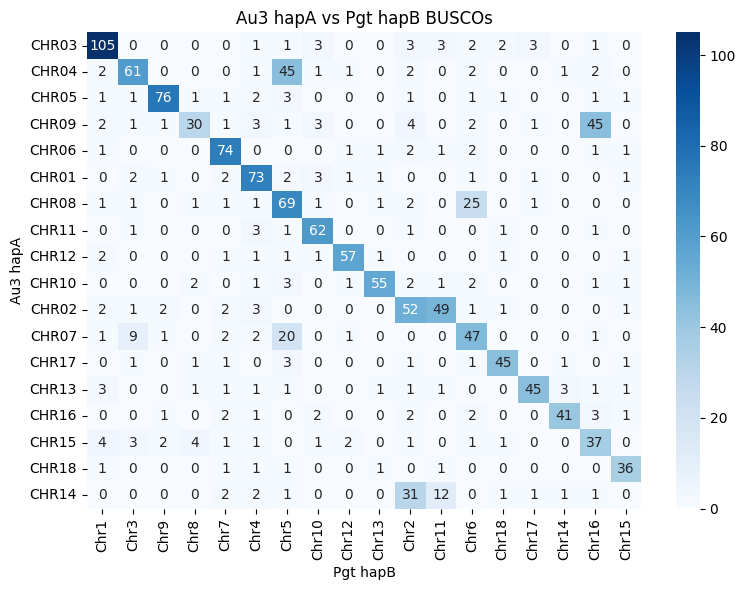

In [37]:
df_Au3_hapA_common = df_Au3_hapA[df_Au3_hapA['BuscoID'].isin(common_Au3_Pgt)]
df_Pgt_hapB_common = df_Pgt_hapB[df_Pgt_hapB['BuscoID'].isin(common_Au3_Pgt)]
#Merge the two dataframes on 'BuscoID'
df_Au3_Pgt_merged = pd.merge(df_Au3_hapA_common, df_Pgt_hapB_common, on='BuscoID', suffixes=('_Au3_A', '_Pgt_B'))
df_Au3_Pgt_merged_count = df_Au3_Pgt_merged.groupby(['SeqName_Au3_A', 'SeqName_Pgt_B']).size().reset_index()
df_Au3_Pgt_merged_count.columns = ['SeqName_Au3_A', 'SeqName_Pgt_B', 'Count']
df_Au3_Pgt_merged_count['SeqName_Au3_A'] = df_Au3_Pgt_merged_count['SeqName_Au3_A'].str.split('_').str[-1]
df_Au3_Pgt_merged_count['SeqName_Pgt_B'] = "Chr" +df_Au3_Pgt_merged_count['SeqName_Pgt_B'].str.split('_').str[-1]
df_Au3_Pgt_merged_count = df_Au3_Pgt_merged_count.sort_values(by=['Count', 'SeqName_Au3_A', 'SeqName_Pgt_B'], ascending=False)
#Generate a pivot table
df_Au3_Pgt_pivot = df_Au3_Pgt_merged_count.pivot(index='SeqName_Au3_A', columns='SeqName_Pgt_B', values='Count').fillna(0)
#Sort order with the columns of df_Au3_Pgt_merged_count
df_Au3_Pgt_pivot = df_Au3_Pgt_pivot.reindex(columns=tmp_orderpgt)
#sort index
df_Au3_Pgt_pivot = df_Au3_Pgt_pivot.reindex(index=tmp_orderau3)
#Generate a heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(df_Au3_Pgt_pivot, annot=True, fmt=".0f", cmap='Blues')
plt.title('Au3 hapA vs Pgt hapB BUSCOs')
plt.xlabel('Pgt hapB')
plt.ylabel('Au3 hapA')
plt.tight_layout()
plt.show()

In [33]:
df_Au3_Pgt_pivot

SeqName_Pgt_A,Chr1,Chr3,Chr9,Chr8,Chr7,Chr4,Chr5,Chr10,Chr12,Chr13,Chr2,Chr11,Chr6,Chr18,Chr17,Chr14,Chr16,Chr15
SeqName_Au3_A,,,,,,,,,,,,,,,,,,
CHR01,0.0,3.0,1.0,0.0,2.0,73.0,1.0,3.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
CHR02,2.0,1.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,52.0,50.0,1.0,1.0,0.0,0.0,0.0,1.0
CHR03,105.0,0.0,0.0,1.0,0.0,1.0,1.0,3.0,0.0,0.0,3.0,3.0,2.0,2.0,3.0,0.0,0.0,0.0
CHR04,2.0,104.0,0.0,1.0,0.0,1.0,2.0,1.0,1.0,0.0,2.0,0.0,2.0,0.0,0.0,1.0,1.0,0.0
CHR05,1.0,1.0,76.0,1.0,1.0,2.0,3.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
CHR06,1.0,0.0,0.0,0.0,74.0,0.0,0.0,0.0,1.0,1.0,2.0,1.0,2.0,0.0,0.0,0.0,1.0,1.0
CHR07,1.0,2.0,1.0,1.0,2.0,2.0,27.0,0.0,1.0,0.0,0.0,0.0,47.0,0.0,0.0,0.0,0.0,0.0
CHR08,1.0,2.0,0.0,1.0,1.0,1.0,68.0,1.0,0.0,1.0,2.0,0.0,25.0,0.0,1.0,0.0,0.0,0.0
CHR09,2.0,1.0,1.0,75.0,1.0,3.0,1.0,3.0,0.0,0.0,4.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0


In [30]:
df_Au3_Pgt_pivot

SeqName_Pgt_A,Chr1,Chr1,Chr1,Chr1,Chr1,Chr1,Chr1,Chr1,Chr1,Chr1,...,Chr8,Chr8,Chr8,Chr9,Chr9,Chr9,Chr9,Chr9,Chr9,Chr9
SeqName_Au3_A,,,,,,,,,,,,,,,,,,,,,
CHR01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
CHR02,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,0.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
CHR03,105.0,105.0,105.0,105.0,105.0,105.0,105.0,105.0,105.0,105.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CHR04,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CHR05,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,76.0,76.0,76.0,76.0,76.0,76.0,76.0
CHR06,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CHR07,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
CHR08,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CHR09,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,75.0,75.0,75.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [27]:
df_Au3_Pgt_merged_count.sort_values(by=['Count', 'SeqName_Au3_A', 'SeqName_Pgt_A'], ascending=False)

,SeqName_Au3_A,SeqName_Pgt_A,Count
21,CHR03,Chr1,105
37,CHR04,Chr3,104
53,CHR05,Chr9,76
92,CHR09,Chr8,75
62,CHR06,Chr7,74
...,...,...,...
7,CHR01,Chr5,1
4,CHR01,Chr17,1
3,CHR01,Chr15,1
2,CHR01,Chr13,1


In [24]:
df_Au3_Pgt_pivot

SeqName_Pgt_A,Chr1,Chr2,Chr3,Chr4,Chr5,Chr6,Chr7,Chr8,Chr9,Chr10,Chr11,Chr12,Chr13,Chr14,Chr15,Chr16,Chr17,Chr18
SeqName_Au3_A,,,,,,,,,,,,,,,,,,
CHR01,0.0,0.0,3.0,73.0,1.0,1.0,2.0,0.0,1.0,3.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
CHR02,2.0,52.0,1.0,2.0,0.0,1.0,2.0,0.0,2.0,0.0,50.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
CHR03,105.0,3.0,0.0,1.0,1.0,2.0,0.0,1.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0
CHR04,2.0,2.0,104.0,1.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
CHR05,1.0,1.0,1.0,2.0,3.0,1.0,1.0,1.0,76.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
CHR06,1.0,2.0,0.0,0.0,0.0,2.0,74.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0
CHR07,1.0,0.0,2.0,2.0,27.0,47.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
CHR08,1.0,2.0,2.0,1.0,68.0,25.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
CHR09,2.0,4.0,1.0,3.0,1.0,2.0,1.0,75.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [30]:
df_Pgt_hapA_common = df_Pgt_hapA[df_Pgt_hapA['BuscoID'].isin(common_Pgt_hapA_hapB)]
df_Pgt_hapB_common = df_Pgt_hapB[df_Pgt_hapB['BuscoID'].isin(common_Pgt_hapA_hapB)]
#Merge the two dataframes on 'BuscoID'
df_Pgt_merged = pd.merge(df_Pgt_hapA_common, df_Pgt_hapB_common, on='BuscoID', suffixes=('_hapA', '_hapB'))
df_Pgt_merged_count = df_Pgt_merged.groupby(['SeqName_hapA', 'SeqName_hapB']).size().reset_index()
df_Pgt_merged_count.columns = ['SeqName_hapA', 'SeqName_hapB', 'Count']
df_Pgt_merged_count['SeqName_hapA'] = "Chr" +df_Pgt_merged_count['SeqName_hapA'].str.split('_').str[-1]
df_Pgt_merged_count['SeqName_hapB'] = "Chr" +df_Pgt_merged_count['SeqName_hapB'].str.split('_').str[-1]
#Generate a pivot table
df_Pgt_pivot = df_Pgt_merged_count.pivot(index='SeqName_hapA', columns='SeqName_hapB', values='Count').fillna(0)
#Reorder the rows and columns
chromosome_order = [f'Chr{i}' for i in range(1, 19)]
df_Pgt_pivot = df_Pgt_pivot.reindex(index=chromosome_order, columns=chromosome_order)
#Generate a heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(df_Pgt_pivot, annot=True, fmt=".0f", cmap='Blues')
plt.title('Pgt hapA vs hapB BUSCOs')
plt.xlabel('Pgt hapB')
plt.ylabel('Pgt hapA')
plt.tight_layout()
plt.savefig("Pgt_hapA_vs_hapB_BUSCOs.svg", format='svg')
plt.show()

/tmp/ipykernel_971/2435371883.py:24: UserWarning: FigureCanvasSVG is non-interactive, and thus cannot be shown
  plt.show()


In [9]:
df_Melli = pd.read_csv('../../data/Melli_full_table.tsv', header=None, sep='\t', comment='#')
df_Melli = df_Melli.iloc[:, [0, 1,2]]
df_Melli.columns = ['BuscoID', 'Status', 'SeqName']

df_Melli = df_Melli[(df_Melli['Status'] != 'Missing') & (df_Melli['Status'] != 'Fragmented')]
df_Melli = df_Melli[df_Melli['BuscoID'].isin(busco_id_Au3_hapA)]
#Merge the two dataframes on 'BuscoID'
df_Au3_Melli_merged = pd.merge(df_Au3_hapA, df_Melli, on='BuscoID', suffixes=('_Au3_A', '_Melli'))
df_Au3_Melli_merged_count = df_Au3_Melli_merged.groupby(['SeqName_Au3_A', 'SeqName_Melli']).size().reset_index()                 
df_Au3_Melli_merged_count.columns = ['SeqName_Au3_A', 'SeqName_Melli', 'Count']
df_Au3_Melli_merged_count['SeqName_Au3_A'] = df_Au3_Melli_merged_count['SeqName_Au3_A'].str.split('_').str[-1]
df_Au3_Melli_merged_count['SeqName_Melli'] = df_Au3_Melli_merged_count['SeqName_Melli'].str.replace('_', '').str.replace('scaffold', 'Chr')
df_Au3_Melli_merged_count = df_Au3_Melli_merged_count.sort_values(by=['SeqName_Au3_A', 'Count', 'SeqName_Melli'], ascending=False)
#df_Au3_Melli_merged_count = df_Au3_Melli_merged_count.pivot(index='SeqName_Au3_A', columns='SeqName_Melli', values='Count').fillna(0)
chromosome_order =  [f"CHR{i:02d}" for i in range(1, 19)]
#make df_Au3_Melli_merged_count sort SeqName_Au3_A same order as chromosome_order
df_Au3_Melli_merged_count = df_Au3_Melli_merged_count.set_index('SeqName_Au3_A').loc[chromosome_order].reset_index()
#Keep the first occurrence of each SeqName_Au3_A
tmp_abundance = df_Au3_Melli_merged_count.drop_duplicates(subset=['SeqName_Au3_A'], keep='first')
columns_order = tmp_abundance['SeqName_Melli'].tolist()
df_Au3_Melli_merged_count = df_Au3_Melli_merged_count.pivot(index='SeqName_Au3_A', columns='SeqName_Melli', values='Count').fillna(0)
df_Au3_Melli_merged_count = df_Au3_Melli_merged_count.reindex(index=chromosome_order, columns=columns_order)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(df_Au3_Melli_merged_count, annot=True, fmt=".0f", cmap='Blues', vmin=0, vmax=120)
plt.title('Au3 hapA vs Melli BUSCOs')
plt.xlabel('Melli')
plt.ylabel('Au3 hapA')
plt.tight_layout()
plt.savefig("Au3_hapA_vs_Melli_BUSCOs.svg", format='svg')
plt.show()

/tmp/ipykernel_12201/1189031292.py:32: UserWarning: FigureCanvasSVG is non-interactive, and thus cannot be shown
  plt.show()


In [10]:
df_UBRO = pd.read_csv('../../data/UBRO_full_table.tsv', header=None, sep='\t', comment='#')
df_UBRO = df_UBRO.iloc[:, [0, 1,2]]
df_UBRO.columns = ['BuscoID', 'Status', 'SeqName']

df_UBRO = df_UBRO[(df_UBRO['Status'] != 'Missing') & (df_UBRO['Status'] != 'Fragmented')]
df_UBRO = df_UBRO[df_UBRO['BuscoID'].isin(busco_id_Au3_hapA)]
#Merge the two dataframes on 'BuscoID'
df_Au3_UBRO_merged = pd.merge(df_Au3_hapA, df_UBRO, on='BuscoID', suffixes=('_Au3_A', '_UBRO'))
df_Au3_UBRO_merged_count = df_Au3_UBRO_merged.groupby(['SeqName_Au3_A', 'SeqName_UBRO']).size().reset_index()                 
df_Au3_UBRO_merged_count.columns = ['SeqName_Au3_A', 'SeqName_UBRO', 'Count']
df_Au3_UBRO_merged_count['SeqName_Au3_A'] = df_Au3_UBRO_merged_count['SeqName_Au3_A'].str.split('_').str[-1]
df_Au3_UBRO_merged_count['SeqName_UBRO'] = df_Au3_UBRO_merged_count['SeqName_UBRO'].str.replace('_', '').str.replace('scaffold', 'Chr')
df_Au3_UBRO_merged_count = df_Au3_UBRO_merged_count.sort_values(by=['SeqName_Au3_A', 'Count', 'SeqName_UBRO'], ascending=False)
chromosome_order =  [f"CHR{i:02d}" for i in range(1, 19)]
#make df_Au3_UBRO_merged_count sort SeqName_Au3_A same order as chromosome_order
df_Au3_UBRO_merged_count = df_Au3_UBRO_merged_count.set_index('SeqName_Au3_A').loc[chromosome_order].reset_index()
tmp_order = []
for chr_au3 in chromosome_order:
    tmp_abundance = df_Au3_UBRO_merged_count[df_Au3_UBRO_merged_count['SeqName_Au3_A'] == chr_au3].sort_values(by='Count', ascending=False).drop_duplicates(subset=['SeqName_Au3_A'], keep='first')['SeqName_UBRO'].tolist()[0]
    if tmp_abundance not in tmp_order:
        tmp_order.append(tmp_abundance)
    else:
        filtered_df = df_Au3_UBRO_merged_count[df_Au3_UBRO_merged_count['SeqName_Au3_A'] == chr_au3].sort_values(by='Count', ascending=False)
        filtered_df = filtered_df[~filtered_df['SeqName_UBRO'].isin(tmp_order)]
        if not filtered_df.empty:
            tmp_abundance = filtered_df['SeqName_UBRO'].iloc[0]
            tmp_order.append(tmp_abundance)
        else:
            # If no unused SeqName_UBRO found, use the most abundant one again
            tmp_abundance = df_Au3_UBRO_merged_count[df_Au3_UBRO_merged_count['SeqName_Au3_A'] == chr_au3].sort_values(by='Count', ascending=False)['SeqName_UBRO'].iloc[0]
            tmp_order.append(tmp_abundance)
#If there are any SeqName_UBRO not in tmp_order, add them to the end of tmp_order
all_UBRO = df_Au3_UBRO_merged_count['SeqName_UBRO'].unique().tolist()
for chr in all_UBRO:
    if chr not in tmp_order:
        tmp_order.append(chr)
df_Au3_UBRO_merged_count = df_Au3_UBRO_merged_count.pivot(index='SeqName_Au3_A', columns='SeqName_UBRO', values='Count').fillna(0)
df_Au3_UBRO_merged_count = df_Au3_UBRO_merged_count.reindex(index=chromosome_order, columns=tmp_order)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(df_Au3_UBRO_merged_count, annot=True, fmt=".0f", cmap='Blues', vmin=0, vmax=120)
plt.title('Au3 hapA vs UBRO BUSCOs')
plt.xlabel('UBRO')
plt.ylabel('Au3 hapA')
plt.tight_layout()
plt.savefig("Au3_hapA_vs_UBRO_BUSCOs.svg", format='svg')
plt.show()

/tmp/ipykernel_12201/983864029.py:48: UserWarning: FigureCanvasSVG is non-interactive, and thus cannot be shown
  plt.show()


In [11]:
df_apl = pd.read_csv('../../data/apl_full_table.tsv', header=None, sep='\t', comment='#')
df_apl = df_apl.iloc[:, [0, 1,2]]
df_apl.columns = ['BuscoID', 'Status', 'SeqName']

df_apl = df_apl[(df_apl['Status'] != 'Missing') & (df_apl['Status'] != 'Fragmented')]
df_apl = df_apl[df_apl['BuscoID'].isin(busco_id_Au3_hapA)]
#Merge the two dataframes on 'BuscoID'
df_Au3_apl_merged = pd.merge(df_Au3_hapA, df_apl, on='BuscoID', suffixes=('_Au3_A', '_apl'))
df_Au3_apl_merged_count = df_Au3_apl_merged.groupby(['SeqName_Au3_A', 'SeqName_apl']).size().reset_index()                 
df_Au3_apl_merged_count.columns = ['SeqName_Au3_A', 'SeqName_apl', 'Count']
df_Au3_apl_merged_count['SeqName_Au3_A'] = df_Au3_apl_merged_count['SeqName_Au3_A'].str.split('_').str[-1]
df_Au3_apl_merged_count['SeqName_apl'] = df_Au3_apl_merged_count['SeqName_apl'].str.replace('_', '').str.replace('scaffold', 'Chr')
df_Au3_apl_merged_count = df_Au3_apl_merged_count.sort_values(by=['SeqName_Au3_A', 'Count', 'SeqName_apl'], ascending=False)
chromosome_order =  [f"CHR{i:02d}" for i in range(1, 19)]
#make df_Au3_apl_merged_count sort SeqName_Au3_A same order as chromosome_order
df_Au3_apl_merged_count = df_Au3_apl_merged_count.set_index('SeqName_Au3_A').loc[chromosome_order].reset_index()
#If there are any SeqName_apl not in tmp_abundance, add them to the end of tmp_abundance
tmp_order = []
for chr_au3 in chromosome_order:
    tmp_abundance = df_Au3_apl_merged_count[df_Au3_apl_merged_count['SeqName_Au3_A'] == chr_au3].sort_values(by='Count', ascending=False).drop_duplicates(subset=['SeqName_Au3_A'], keep='first')['SeqName_apl'].tolist()[0]
    if tmp_abundance not in tmp_order:
        tmp_order.append(tmp_abundance)
    else:
        filtered_df = df_Au3_apl_merged_count[df_Au3_apl_merged_count['SeqName_Au3_A'] == chr_au3].sort_values(by='Count', ascending=False)
        filtered_df = filtered_df[~filtered_df['SeqName_apl'].isin(tmp_order)]
        if not filtered_df.empty:
            tmp_abundance = filtered_df['SeqName_apl'].iloc[0]
            tmp_order.append(tmp_abundance)
        else:
            # If no unused SeqName_apl found, use the most abundant one again
            tmp_abundance = df_Au3_apl_merged_count[df_Au3_apl_merged_count['SeqName_Au3_A'] == chr_au3].sort_values(by='Count', ascending=False)['SeqName_apl'].iloc[0]
            tmp_order.append(tmp_abundance)
#If there are any SeqName_apl not in tmp_order, add them to the end of tmp_order
all_apl = df_Au3_apl_merged_count['SeqName_apl'].unique().tolist()
for chr in all_apl:
    if chr not in tmp_order:
        tmp_order.append(chr)
df_Au3_apl_merged_count = df_Au3_apl_merged_count.pivot(index='SeqName_Au3_A', columns='SeqName_apl', values='Count').fillna(0)
df_Au3_apl_merged_count = df_Au3_apl_merged_count.reindex(index=chromosome_order, columns=tmp_order)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(df_Au3_apl_merged_count, annot=True, fmt=".0f", cmap='Blues', vmin=0, vmax=120)
plt.title('Au3 hapA vs apl BUSCOs')
plt.xlabel('apl')
plt.ylabel('Au3 hapA')
plt.tight_layout()
plt.savefig("Au3_hapA_vs_apl_BUSCOs.svg", format='svg')

In [24]:
df_apl = pd.read_csv('../../data/apl_full_table.tsv', header=None, sep='\t', comment='#')
df_apl = df_apl.iloc[:, [0, 1,2]]
df_apl.columns = ['BuscoID', 'Status', 'SeqName']

df_apl = df_apl[(df_apl['Status'] != 'Missing') & (df_apl['Status'] != 'Fragmented')]
df_apl = df_apl[df_apl['BuscoID'].isin(busco_id_Au3_hapA)]
#Merge the two dataframes on 'BuscoID'
df_Au3_apl_merged = pd.merge(df_Au3_hapA, df_apl, on='BuscoID', suffixes=('_Au3_A', '_apl'))
df_Au3_apl_merged_count = df_Au3_apl_merged.groupby(['SeqName_Au3_A', 'SeqName_apl']).size().reset_index()                 
df_Au3_apl_merged_count.columns = ['SeqName_Au3_A', 'SeqName_apl', 'Count']
df_Au3_apl_merged_count['SeqName_Au3_A'] = df_Au3_apl_merged_count['SeqName_Au3_A'].str.split('_').str[-1]
df_Au3_apl_merged_count['SeqName_apl'] = df_Au3_apl_merged_count['SeqName_apl'].str.replace('_', '').str.replace('scaffold', 'Chr')
df_Au3_apl_merged_count = df_Au3_apl_merged_count.sort_values(by=['SeqName_Au3_A', 'Count', 'SeqName_apl'], ascending=False)
chromosome_order =  [f"CHR{i:02d}" for i in range(1, 19)]
#make df_Au3_apl_merged_count sort SeqName_Au3_A same order as chromosome_order
df_Au3_apl_merged_count = df_Au3_apl_merged_count.set_index('SeqName_Au3_A').loc[chromosome_order].reset_index()

In [28]:
tmp_abundance

,SeqName_Au3_A,SeqName_apl,Count
306,CHR18,CP060317.1,11
307,CHR18,CP060305.1,7
308,CHR18,CP060303.1,6
309,CHR18,CP060300.1,4
310,CHR18,CP060316.1,3
311,CHR18,CP060299.1,3
312,CHR18,CP060318.1,2
313,CHR18,CP060313.1,2
314,CHR18,CP060307.1,2
315,CHR18,CP060302.1,2


In [ ]:
from scipy.stats import chi2_contingency
chi2, p, dof, ex = chi2_contingency(df_Au3_Pgt_pivot)
print(f"Chi-square test: chi2={chi2}, p-value={p}, dof={dof}")

Chi-square test: chi2=14863.960651118177, p-value=0.0, dof=289


In [42]:
chi2, p, dof, ex = chi2_contingency(df_Au3_Melli_merged_count)
print(f"Chi-square test: chi2={chi2}, p-value={p}, dof={dof}")

Chi-square test: chi2=18335.455774229275, p-value=0.0, dof=289


In [43]:
chi2, p, dof, ex = chi2_contingency(df_Au3_UBRO_merged_count)
print(f"Chi-square test: chi2={chi2}, p-value={p}, dof={dof}")

Chi-square test: chi2=1914.9198192667488, p-value=7.548712749931728e-205, dof=374


In [ ]:
chi2, p, dof, ex = chi2_contingency(df_Au3_UBRO_merged_count)
print(f"Chi-square test: chi2={chi2}, p-value={p}, dof={dof}")

Chi-square test: chi2=1506.5966068528762, p-value=3.4190865350108072e-146, dof=340


In [41]:
len(common_Au3_hapA_hapB), len(common_Pgt_hapA_hapB), len(common_Au3_Pgt)

(1567, 1545, 1427)

In [6]:

print("Au3 hapA busco value:", len(df_Au3_hapA))
print("Au3 hapB busco value:", len(df_Au3_hapB))
print("Pgt hapA busco value:", len(df_Pgt_hapA))
print("Pgt hapB busco value:", len(df_Pgt_hapB))

Au3 hapA busco value: 1593
Au3 hapB busco value: 1587
Pgt hapA busco value: 1585
Pgt hapB busco value: 1602


In [7]:
df_Au3_pairwise = pd.merge(df_Au3_hapA, df_Au3_hapB, on='BuscoID', suffixes=('_Au3_hapA', '_Au3_hapB'))

In [15]:
df_Au3_pairwise.to_csv('20250924_Au3_hapA_hapB_busco_pairwise.csv', sep='\t', index=False,header=True)

In [16]:
df_Pgt_pairwise = pd.merge(df_Pgt_hapA, df_Pgt_hapB, on='BuscoID', suffixes=('_Pgt_hapA', '_Pgt_hapB'))
df_Pgt_pairwise.to_csv('20250924_Pgt_hapA_hapB_busco_pairwise.csv', sep='\t', index=False,header=True)

In [39]:
count_df_Pgt = df_Pgt_pairwise.groupby(['SeqName_Pgt_hapA', 'SeqName_Pgt_hapB']).size().reset_index()
count_df_Pgt.columns = ['SeqName_Pgt_hapA', 'SeqName_Pgt_hapB', 'Count']
count_df_Pgt.to_csv('20250924_Pgt_hapA_hapB_busco_pairwise_count.csv', sep='\t', index=False,header=True)

In [17]:
df_Au3_Pgt = pd.merge(df_Au3, df_Pgt, on='BuscoID', suffixes=('_Au3', '_Pgt'))
df_Au3_Pgt.to_csv('20250924_Au3_Pgt_busco_pairwise.csv', sep='\t', index=False,header=True)

In [35]:
count_df_Au3_Pgt = df_Au3_Pgt.groupby(['Genome_Au3','Genome_Pgt', 'SeqName_Au3', 'SeqName_Pgt']).size().reset_index()
count_df_Au3_Pgt
count_df_Au3_Pgt.columns = ['Genome_Au3','Genome_Pgt', 'SeqName_Au3', 'SeqName_Pgt', 'Count']
count_df_Au3_Pgt.to_csv('20250924_Au3_Pgt_busco_pairwise_count.csv', sep='\t', index=True,header=True)

In [38]:
count_df_Au3 = df_Au3_pairwise.groupby(['SeqName_Au3_hapA', 'SeqName_Au3_hapB']).size().reset_index()
count_df_Au3.columns = ['SeqName_Au3_hapA', 'SeqName_Au3_hapB', 'Count']
count_df_Au3.to_csv('20250924_Au3_hapA_hapB_busco_pairwise_count.csv', sep='\t', index=False,header=True)

In [ ]:
df_Au3_Pgt_hapA.groupby(['SeqName_Au3_hapA', 'SeqName_Au3_hapB']).size()

In [10]:
#join df_Au3_hapA and df_Pgt_hapA on 'BUSCO id' column
df_Au3_Pgt_hapA = pd.merge(df_Au3_hapA, df_Pgt_hapA, on='BuscoID', suffixes=('_Au3_hapA', '_Pgt_hapA'))

In [11]:
df_Au3_Pgt_hapA = pd.merge(df_Au3_hapA, df_Pgt_hapA, on='BuscoID', suffixes=('_Au3_hapA', '_Pgt_hapA'))

In [9]:
df_Au3_Pgt_hapA

,Genome_Au3_hapA,SeqName_Au3_hapA,Start_Au3_hapA,End_Au3_hapA,Strand_Au3_hapA,BuscoID,Genome_Pgt_hapA,SeqName_Pgt_hapA,Start_Pgt_hapA,End_Pgt_hapA,Strand_Pgt_hapA
0,AuhapA,APSI_AU3_HapA_CHR01,648035,649003,+,64982at5204,PgthapA,chr_4,5910336,5911241,+
1,AuhapA,APSI_AU3_HapA_CHR01,1586229,1587021,+,70561at5204,PgthapA,chr_4,5849387,5848286,-
2,AuhapA,APSI_AU3_HapA_CHR01,2320950,2322828,+,53888at5204,PgthapA,chr_4,5857376,5859300,+
3,AuhapA,APSI_AU3_HapA_CHR01,3267396,3263203,-,4662at5204,PgthapA,chr_4,5233526,5237663,+
4,AuhapA,APSI_AU3_HapA_CHR01,4031267,4032278,+,74336at5204,PgthapA,chr_7,2764180,2765501,+
...,...,...,...,...,...,...,...,...,...,...,...
1479,AuhapA,APSI_AU3_HapA_CHR18,20932638,20935210,+,20392at5204,PgthapA,chr_15,321047,318479,-
1480,AuhapA,APSI_AU3_HapA_CHR18,24942053,24940941,-,61882at5204,PgthapA,chr_15,164849,163636,-
1481,AuhapA,APSI_AU3_HapA_CHR18,26040577,26041986,+,32623at5204,PgthapA,chr_15,203960,202520,-
1482,AuhapA,APSI_AU3_HapA_CHR18,26419649,26417892,-,38878at5204,PgthapA,chr_15,367541,365736,-
